# LKP 6 — Morfologi
**Alur:** Load → HSV → Histogram → Threshold → Erosi → Dilasi → Variasi Kernel

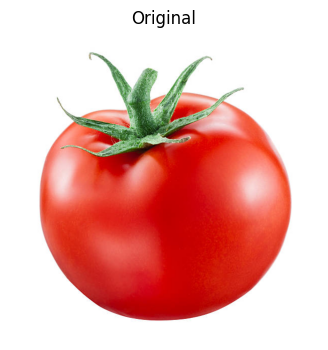

In [184]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('tomato.jpeg')
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

plt.figure(figsize=(4, 4))
plt.imshow(rgb)
plt.title('Original')
plt.axis('off')
plt.show()

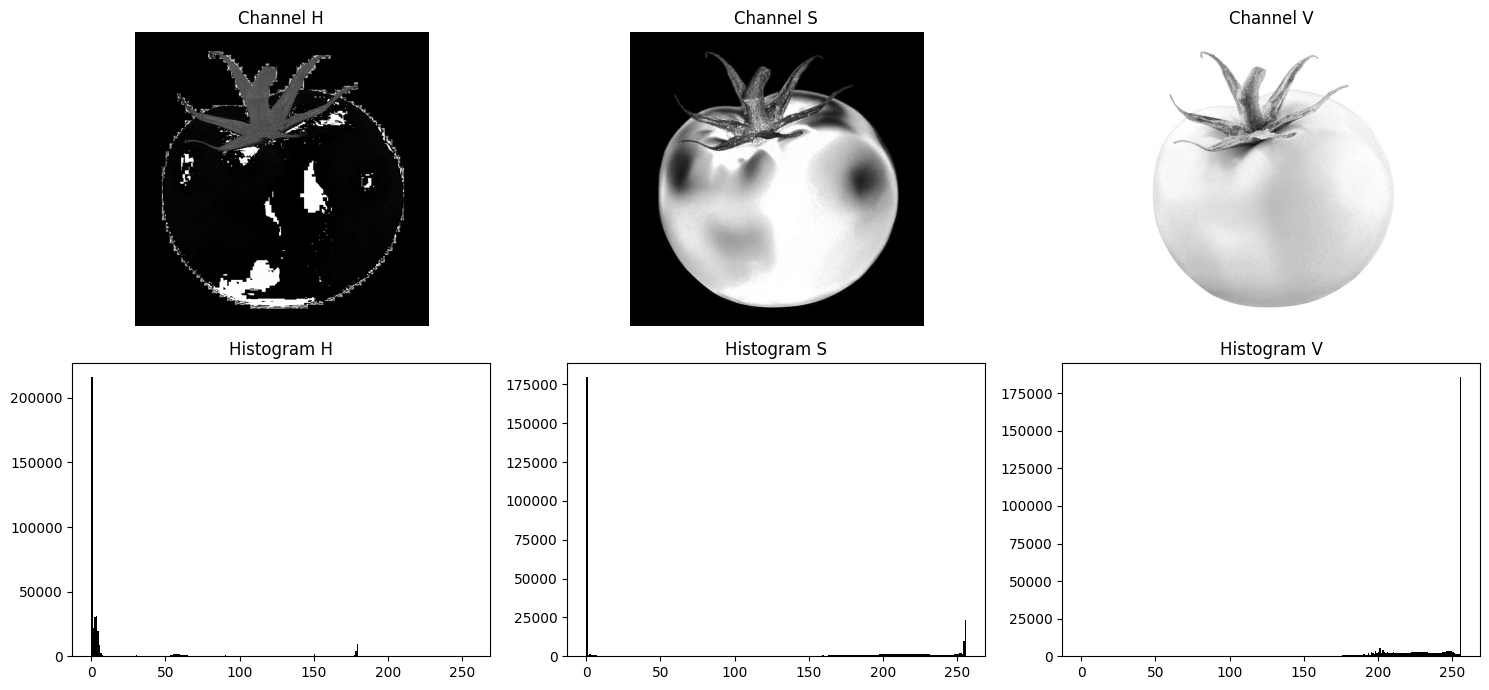

In [185]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for i, (ch, name) in enumerate(zip([h, s, v], ['H', 'S', 'V'])):
    axes[0, i].imshow(ch, cmap='gray')
    axes[0, i].set_title(f'Channel {name}')
    axes[0, i].axis('off')

    axes[1, i].hist(ch.ravel(), bins=256, range=[0, 256], color='black')
    axes[1, i].set_title(f'Histogram {name}')

plt.tight_layout()
plt.show()

## Segmentasi HSV
- **HSV** dipilih karena channel H langsung merepresentasikan warna — ideal untuk objek berwarna spesifik (tomat merah).
- Merah ada di **dua ujung** H (0–15 dan 165–179) karena sifatnya melingkar → perlu 2 mask digabung OR.
- S dan V difilter untuk mengabaikan piksel yang terlalu pudar atau gelap.

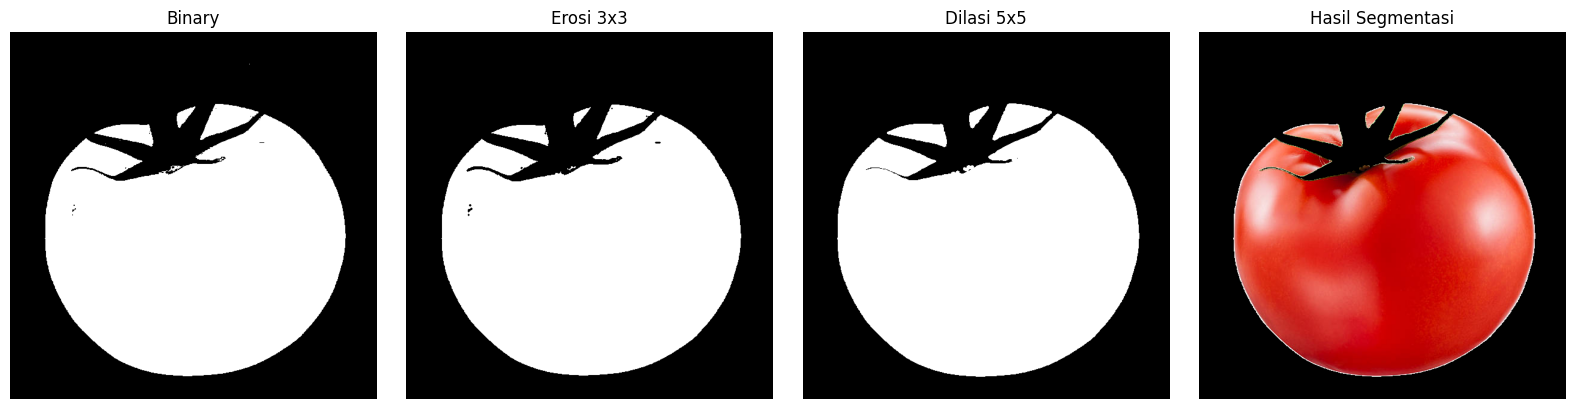

In [186]:
# Thresholding (2 range karena H melingkar)
mask1 = cv2.inRange(hsv, np.array([0, 27, 40]), np.array([15, 255, 255]))
mask2 = cv2.inRange(hsv, np.array([165, 27, 40]), np.array([179, 255, 255]))
binary = cv2.bitwise_or(mask1, mask2)

# Morfologi
k_erosi = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
k_dilasi = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
erosi = cv2.erode(binary, k_erosi)
dilasi = cv2.dilate(erosi, k_dilasi)
hasil = cv2.bitwise_and(rgb, rgb, mask=dilasi)

# Visualisasi pipeline
titles = ['Binary', 'Erosi 3x3', 'Dilasi 5x5', 'Hasil Segmentasi']
imgs = [binary, erosi, dilasi, hasil]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (im, t) in enumerate(zip(imgs, titles)):
    axes[i].imshow(im, cmap='gray' if i < 3 else None)
    axes[i].set_title(t)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## Justifikasi Parameter

| Parameter | Nilai | Alasan |
|---|---|---|
| Color space | HSV | Channel H langsung merepresentasikan warna |
| Threshold H | 0-15, 165-179 | Dari histogram, spike merah di kedua ujung |
| Threshold S | 27-255 | Membuang piksel pudar (highlight/background) |
| Threshold V | 40-255 | Membuang piksel terlalu gelap |
| Erosi | Ellipse 3x3, 1 iter | Buang noise tanpa mengikis objek |
| Dilasi | Ellipse 5x5, 1 iter | Mengembalikan bentuk + menutup celah kecil |

## Variasi Kernel & Iterasi

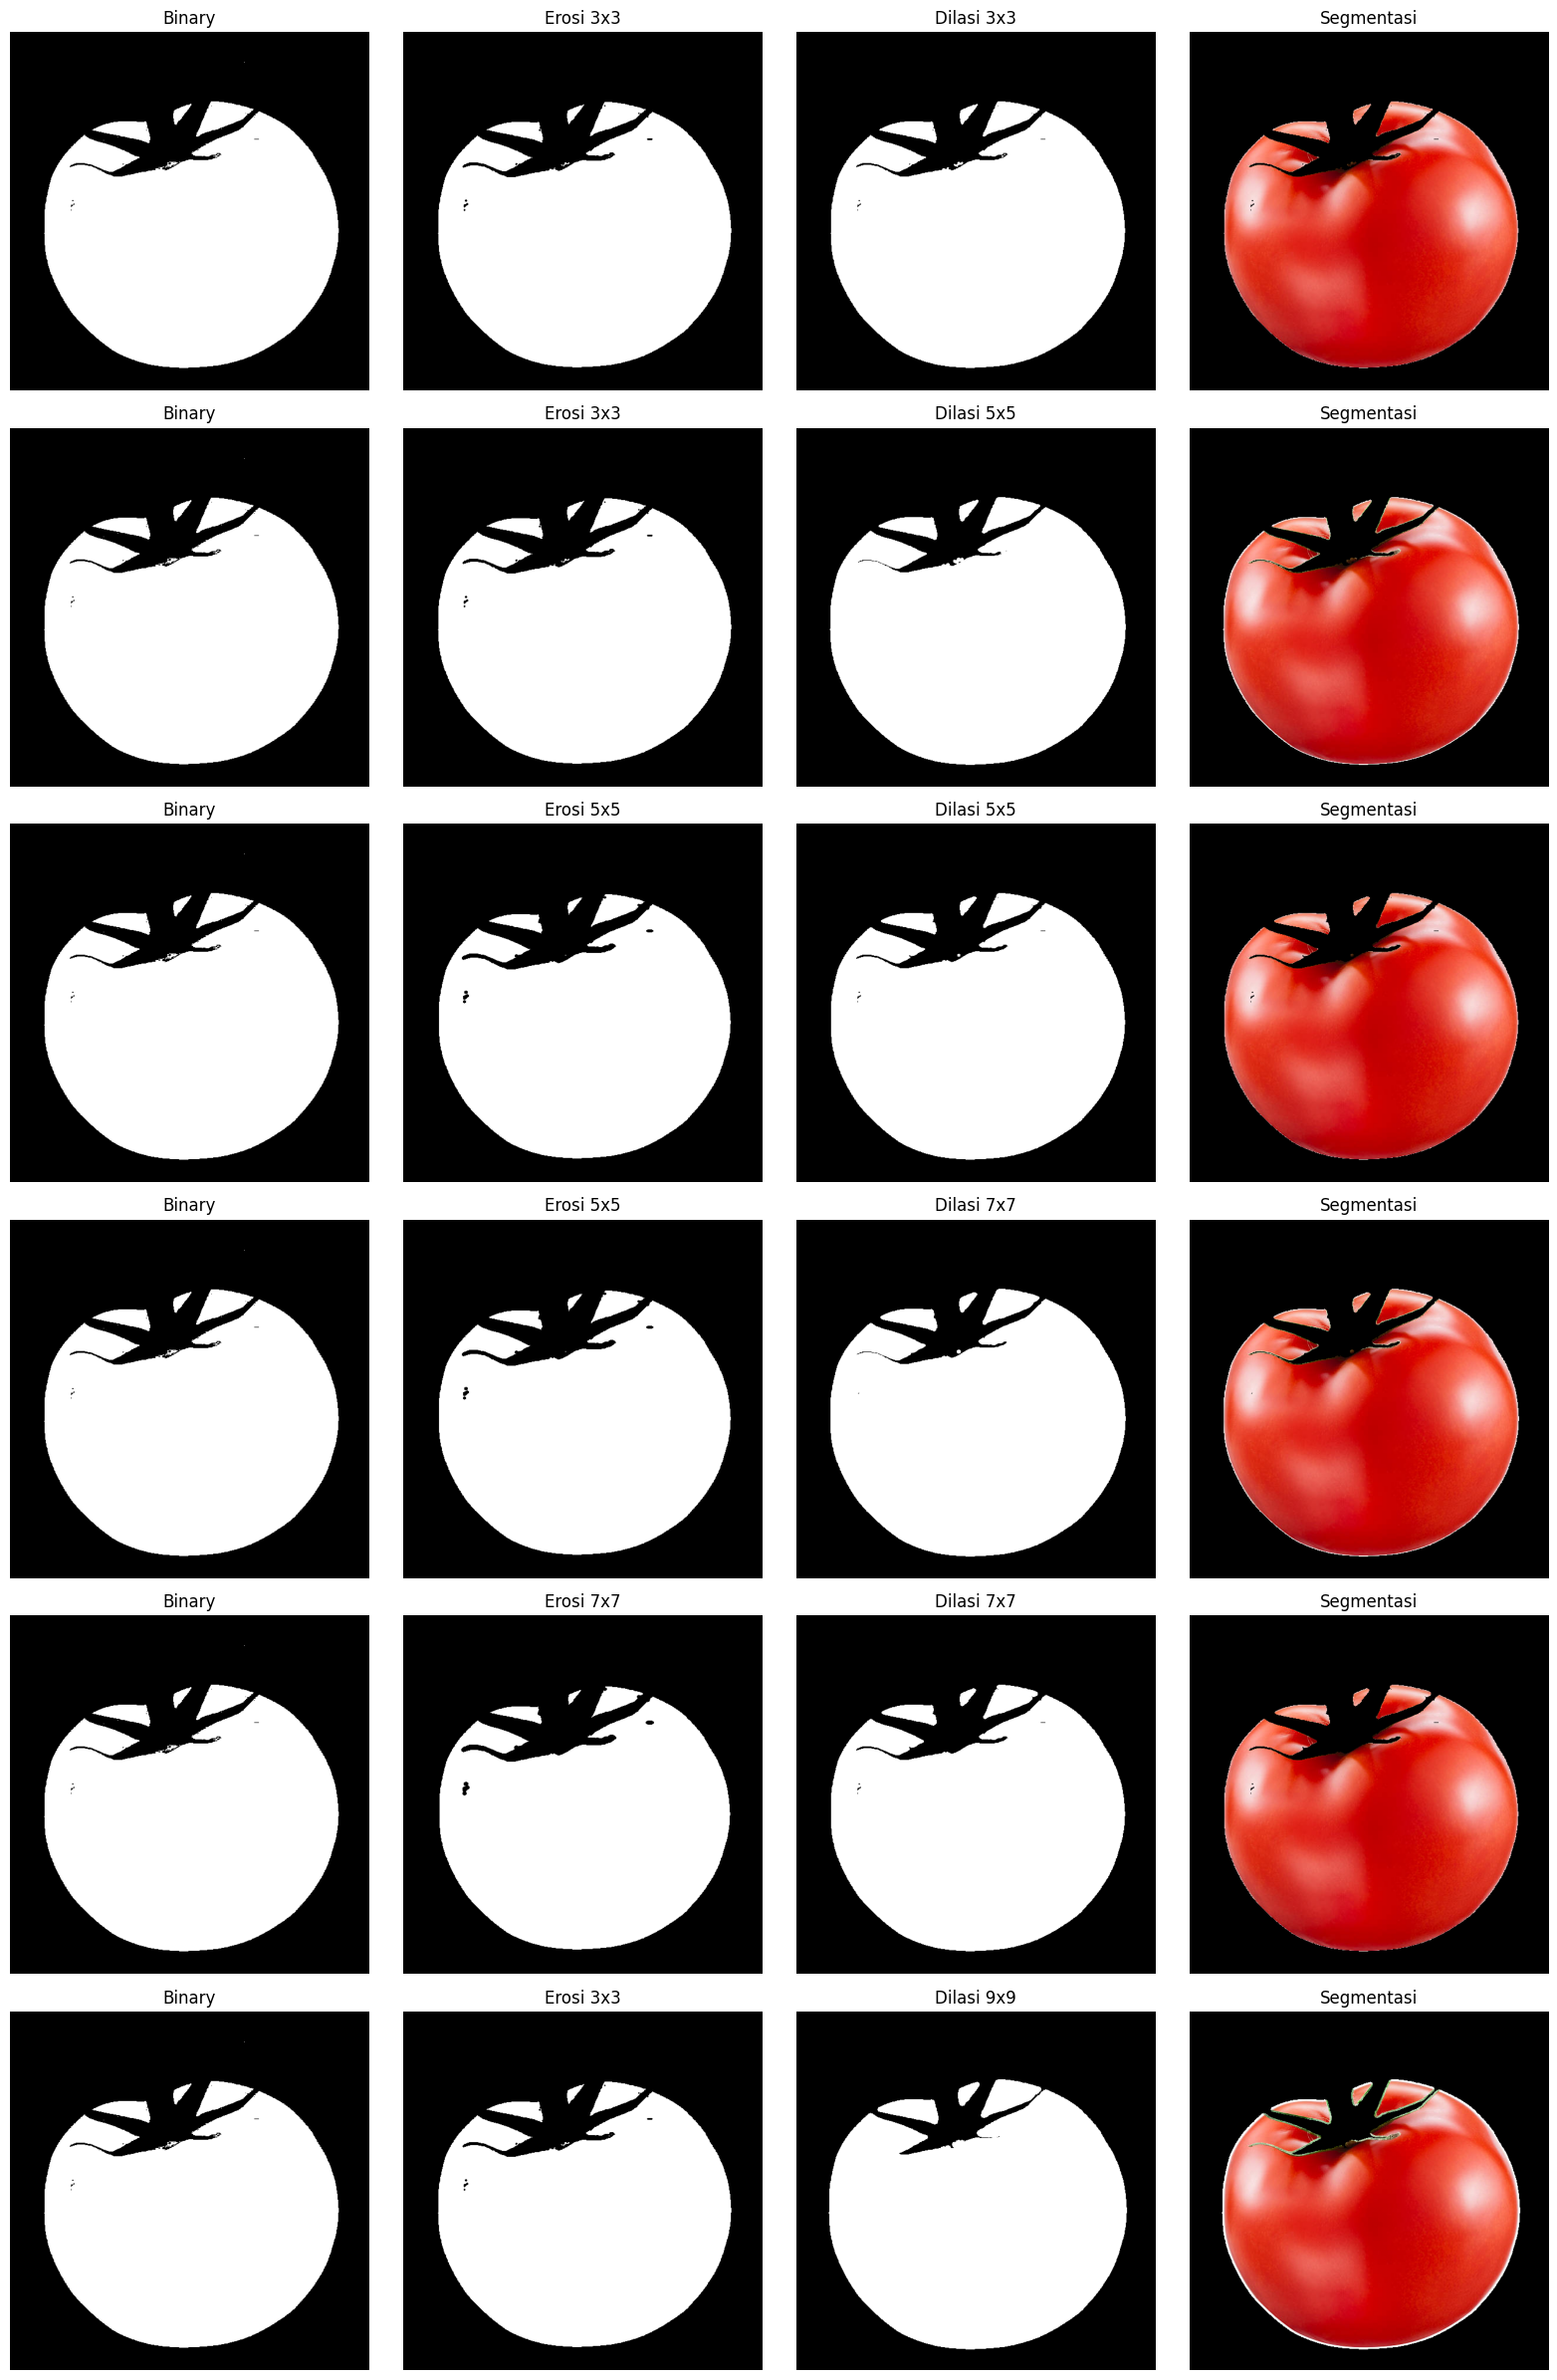

In [ ]:
configs = [
    # (erosi_size, dilasi_size, iter_erosi, iter_dilasi)
    (3, 3, 1, 1),
    (3, 5, 1, 1),   # pilihan akhir
    (5, 5, 1, 1),
    (5, 7, 1, 1),
    (3, 5, 2, 1),
    (3, 5, 1, 2),
]

fig, axes = plt.subplots(len(configs), 4, figsize=(16, 3.5 * len(configs)))

for row, (ke_s, kd_s, ie, id_) in enumerate(configs):
    ke = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ke_s, ke_s))
    kd = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kd_s, kd_s))
    er = cv2.erode(binary, ke, iterations=ie)
    dl = cv2.dilate(er, kd, iterations=id_)
    seg = cv2.bitwise_and(rgb, rgb, mask=dl)

    for col, (im, ttl) in enumerate(zip(
        [binary, er, dl, seg],
        ['Binary', f'Erosi {ke_s}x{ke_s} i={ie}', f'Dilasi {kd_s}x{kd_s} i={id_}', 'Hasil']
    )):
        axes[row, col].imshow(im, cmap='gray' if col < 3 else None)
        axes[row, col].set_title(ttl, fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Kesimpulan
- **Kernel kecil** (3x3) menjaga detail tepi, **kernel besar** (7x7+) lebih agresif tapi mengikis bentuk.
- **Iterasi tinggi** memperkuat efek — erosi makin menyusutkan, dilasi makin melebarkan.
- **Pilihan akhir: erosi 3x3 + dilasi 5x5 (masing-masing 1 iter)** — keseimbangan terbaik antara noise removal dan preservasi bentuk.